In [27]:
############################“能量台阶”+“能量差值”数据提取##############################
import os
import pandas as pd

# 获取当前目录下所有的xlsx文件
xlsx_files = [f for f in os.listdir('.') if f.endswith('.xlsx')]

# 初始化两个空的DataFrame，一个用于台阶数据，一个用于能量差值
total_df_steps = pd.DataFrame()
total_df_diff = pd.DataFrame()

# 读取每个xlsx文件并提取“台阶数据”和“能量差值”列的数据
for i, xlsx_file in enumerate(xlsx_files):
    df = pd.read_excel(xlsx_file)
    model_name = xlsx_file.split('.')[0]  # 获取模型名称
    total_df_steps[model_name] = df['台阶数据'].tolist()  # 添加台阶数据到新的DataFrame
    total_df_diff[model_name] = df['能量差值'].tolist()  # 添加能量差值数据到新的DataFrame

# 生成第一列的递增数列
total_df_steps.insert(0, '递增数列', list(range(1, len(total_df_steps) + 1)))
total_df_diff.insert(0, '递增数列', list(range(1, len(total_df_diff) + 1)))

# 将汇总的数据写入到新的Excel文件中
total_df_steps.to_excel("gibbs_free_energy.xlsx", index=False)
total_df_diff.to_excel("energy_diff.xlsx", index=False)


In [28]:
###############################台阶数据复制5次######################
import pandas as pd
import numpy as np

# 读取Excel文件
df = pd.read_excel('gibbs_free_energy.xlsx')

# 创建一个新的空DataFrame
new_df = pd.DataFrame()

# 对df的每一列进行处理
for column in df.columns:
    if column != '递增数列':
        # 重复每一个值5次
        new_df[column] = df[column].repeat(5).reset_index(drop=True)

# 生成新的“递增数列”数据
new_df['递增数列'] = np.tile(np.arange(1, 6), len(df)) + np.repeat(np.arange(0, len(df)) * 10, 5)

# 将 '递增数列' 列移动到第一列
cols = new_df.columns.tolist()
cols.insert(0, cols.pop(cols.index('递增数列')))
new_df = new_df[cols]

# 保存到新的Excel文件
new_df.to_excel('gibbs_free_energy_repeated.xlsx', index=False)


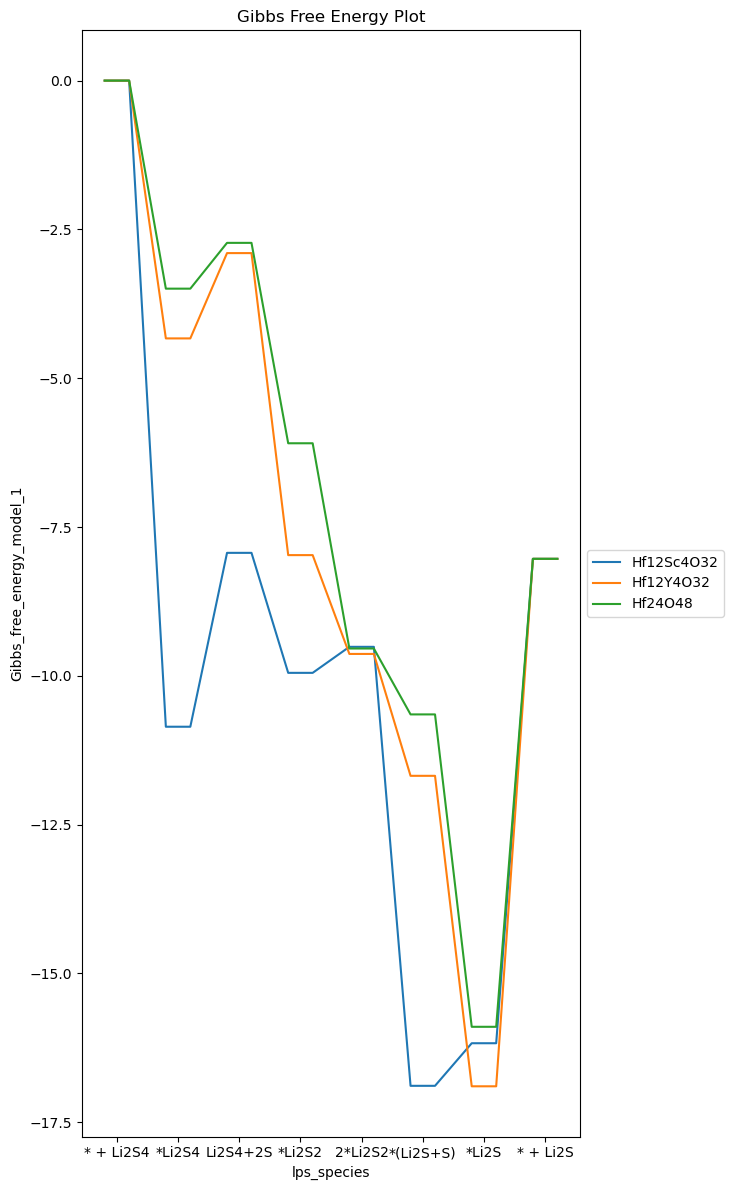

In [29]:
#############################数据画图#############################
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 读取数据
df = pd.read_excel("gibbs_free_energy_repeated.xlsx")

# 设置图像大小
#plt.figure(figsize=(10, 6))
# 设置图像大小
plt.figure(figsize=(6, 12))

# 循环遍历每一列（除了'递增数列'列）
for column in df.columns[1:]:
    plt.plot(np.array(df['递增数列']), np.array(df[column]), label=column)

# 添加图例
plt.legend()

# 添加标题和轴标签
plt.title('Gibbs Free Energy Plot')
plt.xlabel('lps_species')
plt.ylabel('Gibbs_free_energy_model_1')
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# 替换x轴的标签
x_labels = ["* + Li2S4", "*Li2S4","Li2S4+2S", "*Li2S2", "2*Li2S2", "*(Li2S+S)", "*Li2S", "* + Li2S"]
plt.xticks(range(3, 78, 10), x_labels)

plt.savefig('data.png', dpi=300)
# 显示图像
plt.show()


In [30]:
################Gibbs_rds数据提取_不包含吸附和脱附的行########################
import os
import pandas as pd

# 读取 energy_diff 数据
df = pd.read_excel("energy_diff.xlsx")

# 创建一个空的DataFrame，用于存储每个模型的最大能量差值
max_energy_diff_df = pd.DataFrame(columns=['Model', 'Max Energy Diff'])

# 选取第三和第四行的数据（Python 的索引从 0 开始，所以第三和第四行的索引是 2 和4）
selected_rows = df.iloc[2:5]

# 遍历每一个模型，并在选定的行中找出每个模型的最大能量差值
for column in selected_rows.columns[1:]:
    max_energy_diff = selected_rows[column].max()
    new_row = pd.DataFrame({'Model': [column], 'Max Energy Diff': [max_energy_diff]})
    max_energy_diff_df = pd.concat([max_energy_diff_df, new_row])

# 将最大能量差值数据写入新的 Excel 文件
max_energy_diff_df.to_excel("energy_diff_max_1.xlsx", index=False)
